In [7]:
'''
==========================================================================
                                PROBLEM-1
==========================================================================
'''
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
import os

# ==========================================
# STEP 1: LOAD DATASETS
# ==========================================
#The following  variables are used to store paths for the datasets. so that you do not need to write the entire path every time.
#The entire code will be using these variables,so you update them.
# You can change these paths easily to your uploaded file names (e.g., 'train.csv', 'test.csv')
TRAIN_DATA_PATH = "BT2024181_train_var1.csv"
TEST_DATA_PATH = "BT2024181_test_var1.csv"

# Fallback paths in case the files are located in your Drive folder
#Incase you are using google drive paths to access the datasets, you can put them here.
DRIVE_TRAIN_PATH = "/content/drive/MyDrive/ml-assignment-datasets/BT2024181_train_var1.csv"
DRIVE_TEST_PATH = "/content/drive/MyDrive/ml-assignment-datasets/BT2024181_test_var1.csv"

#now this function loads the datasets usign the path variables given above.
def load_dataset(file_path, fallback_path=None):
    """Helper function to search for dataset at primary path, fallback path, or current directory."""
    target_path = file_path
    if not os.path.exists(target_path):
        if fallback_path and os.path.exists(fallback_path):
            target_path = fallback_path
        else:
            # Try searching in the current directory as a last resort
            filename = os.path.basename(file_path)
            if os.path.exists(filename):
                target_path = filename
            else:
                return None

    print(f"Successfully loading dataset from: {target_path}")
    return pd.read_csv(target_path)

# Load Training Data. we load the training set into the train_df dataframe.
train_df = load_dataset(TRAIN_DATA_PATH, DRIVE_TRAIN_PATH)

#if the load is successful and dataset gets loaded.we split the label column and the feature columns into X_train_full for features and y_train_full for label column.
if train_df is not None:
    # Train set has 7 columns: x1, x2, x3, x4, x5, x6, y
    X_train_full = train_df.iloc[:, :6].values
    #we also convert the label column into a numpy column vector
    y_train_full = train_df.iloc[:, 6].values.reshape(-1, 1)
else:
    #incase the dataset never got loaded.
    raise FileNotFoundError("Training dataset not found! Please upload your train dataset file directly or correct the TRAIN_DATA_PATH/DRIVE_TRAIN_PATH variables.")

# Polynomial regression Model Definition
#This is the model class that we will be using in our code for our model.
class PolyRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(PolyRegressionModel, self).__init__()
        #we got linear layer representation(linear in paramters) for our polynomial (x^2,x1x2...) features.
        self.linear = nn.Linear(input_dim, 1)

    #method computing the predicted label(y^)
    def forward(self, x):
        return self.linear(x)

#Training function for our model
#This method uses our model and runs its for some epochs using a learning rate.
def train_pytorch_model(X_train, y_train, epochs=1500, lr=0.01):
    """Helper function to train a simple linear layer in PyTorch with L2 regularization."""

    #we convert our X_train,y_train to pytorch tensors to perform operations on them.
    X_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_tensor = torch.tensor(y_train, dtype=torch.float32)
    #we initialize a regression model
    model = PolyRegressionModel(X_train.shape[1])
    #setting up the mse loss calculator
    criterion = nn.MSELoss()
    #in here, weight decay is our lambda parameter in l2-regularization.
    #lr is learning rate that we use in gradient descent to find optimal weights for loss function
    #we initialize a optimizer object to do gradient descent.
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    #for every epoch
    for epoch in range(epochs):
      #train the model
        model.train()
        #clear the gradients from previous epoch,so that they dont accumulate and add up
        optimizer.zero_grad()
        #do prediction
        predictions = model(X_tensor)
        #compute loss
        loss = criterion(predictions, y_tensor)
        #based on that update weights
        #we compute the gradient here
        loss.backward()
        #we perform weight update here
        optimizer.step()

    return model

# ==========================================
# STEP 2: FIND OPTIMAL POLYNOMIAL DEGREE & LR (K-Fold CV)
# ==========================================
k_folds = 4 #number of parts that i am dividing the dataset into
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42) #initializing the k-fold object from kfold class

# Hyperparameters to search over
learning_rates_to_check = [0.1, 0.05, 0.01, 0.005, 0.001]
max_degree_to_check = 10

best_degree = 1 #this variable stores the best degree we will obtain.
best_lr = 0.01 #this variable stores the best learning rate we will obtain.
#iniatializing dummy values into variables
lowest_avg_mse = float('inf')
best_avg_r2 = -float('inf')
#max degree till where we will check
max_degree_to_check = 10

print(f"\nStarting {k_folds}-Fold Cross Validation to find optimal polynomial degree and learning rate...")

for degree in range(1, max_degree_to_check + 1):
    #to add interaction terms we set up a tranformer ready for action.
    poly = PolynomialFeatures(degree=degree, include_bias=False)

    for lr_cand in learning_rates_to_check:
        fold_mses = []
        fold_r2s = []

        for train_idx, val_idx in kf.split(X_train_full):
            # Split data
            X_fold_train, X_fold_val = X_train_full[train_idx], X_train_full[val_idx]
            y_fold_train, y_fold_val = y_train_full[train_idx], y_train_full[val_idx]

            # Transform to Polynomial Features
            #adding the polynomial features like x^2,x^3 and interaction terms like x1x2....
            X_fold_train_poly = poly.fit_transform(X_fold_train)
            X_fold_val_poly = poly.transform(X_fold_val)

            # Scale Features
            scaler = StandardScaler()
            #we learn scaling from train set and apply it on test set.
            X_fold_train_scaled = scaler.fit_transform(X_fold_train_poly)
            X_fold_val_scaled = scaler.transform(X_fold_val_poly)

            # Train PyTorch Model
            model = train_pytorch_model(X_fold_train_scaled, y_fold_train, epochs=1200, lr=lr_cand)

            # Evaluate
            model.eval()
            with torch.no_grad():
              #we convert the scaled part of dataset into a tensor for pytorch.
                X_val_tensor = torch.tensor(X_fold_val_scaled, dtype=torch.float32)
                #finding y_pred
                y_pred_val = model(X_val_tensor).numpy()

            #finding and addind mse and r2 values for this fold iteration into the arrays.
            fold_mse = mean_squared_error(y_fold_val, y_pred_val)
            fold_r2 = r2_score(y_fold_val, y_pred_val)

            fold_mses.append(fold_mse)
            fold_r2s.append(fold_r2)

        #in the end we find average mse and average r2 values
        avg_mse = np.mean(fold_mses)
        avg_r2 = np.mean(fold_r2s)

        print(f"Degree {degree} | LR {lr_cand}: Avg MSE = {avg_mse:.4f} | Avg R2 = {avg_r2:.4f}")

        #we compare and stored best values
        if avg_mse < lowest_avg_mse:
            lowest_avg_mse = avg_mse
            best_avg_r2 = avg_r2
            best_degree = degree
            best_lr = lr_cand

print("\n" + "="*50)
print(f"OPTIMAL SETUP: Degree {best_degree} with LR {best_lr} (Lowest Avg MSE: {lowest_avg_mse:.4f}, R2: {best_avg_r2:.4f})")
print("="*50 + "\n")

# ==========================================
# STEP 3: TRAIN ON ENTIRE TRAIN SET & PREDICT
# ==========================================
print(f"Training final model on full training data with Optimal Degree {best_degree} and LR {best_lr}...")
##now that we know optimal degree,we will train it using the entire dataset and test it on test set and store predictions.
#setting up the transformer
final_poly = PolynomialFeatures(degree=best_degree, include_bias=False)
#adding the polynomial features
X_train_final_poly = final_poly.fit_transform(X_train_full)
#scaling the dataset features
final_scaler = StandardScaler()
X_train_final_scaled = final_scaler.fit_transform(X_train_final_poly)

# Train final PyTorch model with the best parameters and more training iterations
final_model = train_pytorch_model(X_train_final_scaled, y_train_full, epochs=2500, lr=best_lr)
#after training, now we test.
# Load Test Data
test_df = load_dataset(TEST_DATA_PATH, DRIVE_TEST_PATH)
if test_df is not None:
    # Ensure we use exactly the first 6 columns as features
    X_test = test_df.iloc[:, :6].values

    # Transform test data using fitted poly and scaler so that same scaling from training set is applied here.
    X_test_poly = final_poly.transform(X_test)
    X_test_scaled = final_scaler.transform(X_test_poly)

    # Predict
    #to switch the model into evaluation mode.
    final_model.eval()
    #to tell pytorch not to store gradient history
    with torch.no_grad():
      #conversion to tensor
        X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
        #predicting y_test_pred
        y_test_pred = final_model(X_test_tensor).numpy().flatten()

    # Save predictions to 'predictions1.csv'
    output_df = pd.DataFrame({
        'index': test_df.index,
        'predicted_y': y_test_pred
    })
    output_df.to_csv('predictions1.csv', index=False)
    print("\n--- PREDICTIONS GENERATED ---")
    print("Successfully saved final model predictions to 'predictions1.csv'!")
else:
    print(f"\nTest set file not found. Upload the test file to see predictions.")

Successfully loading dataset from: /content/drive/MyDrive/ml-assignment-datasets/BT2024181_train_var1.csv

Starting 4-Fold Cross Validation to find optimal polynomial degree and learning rate...
Degree 1 | LR 0.1: Avg MSE = 9.0089 | Avg R2 = 0.1149
Degree 1 | LR 0.05: Avg MSE = 9.0089 | Avg R2 = 0.1149
Degree 1 | LR 0.01: Avg MSE = 9.0089 | Avg R2 = 0.1149
Degree 1 | LR 0.005: Avg MSE = 9.0089 | Avg R2 = 0.1149
Degree 1 | LR 0.001: Avg MSE = 9.0446 | Avg R2 = 0.1122
Degree 2 | LR 0.1: Avg MSE = 3.0046 | Avg R2 = 0.7046
Degree 2 | LR 0.05: Avg MSE = 3.0046 | Avg R2 = 0.7046
Degree 2 | LR 0.01: Avg MSE = 3.0046 | Avg R2 = 0.7046
Degree 2 | LR 0.005: Avg MSE = 3.0043 | Avg R2 = 0.7046
Degree 2 | LR 0.001: Avg MSE = 3.4922 | Avg R2 = 0.6562
Degree 3 | LR 0.1: Avg MSE = 0.9425 | Avg R2 = 0.9068
Degree 3 | LR 0.05: Avg MSE = 0.9423 | Avg R2 = 0.9069
Degree 3 | LR 0.01: Avg MSE = 0.9426 | Avg R2 = 0.9068
Degree 3 | LR 0.005: Avg MSE = 0.9415 | Avg R2 = 0.9069
Degree 3 | LR 0.001: Avg MSE = 1.

       PROBLEM 1: DYNAMIC VALIDATION ANALYSIS BY DEGREE     


degree,best_lr,avg_mse,avg_r2
1,0.001000,9.014800,0.115000
2,0.100000,3.004300,0.704600
3,0.100000,0.942400,0.906800
4,0.005000,0.800200,0.921100
5,0.001000,0.697000,0.931600
6,0.001000,0.826200,0.919000
7,0.001000,1.174200,0.885000
8,0.001000,1.353200,0.866300
9,0.050000,1.918300,0.813500
10,0.005000,1.768900,0.827100


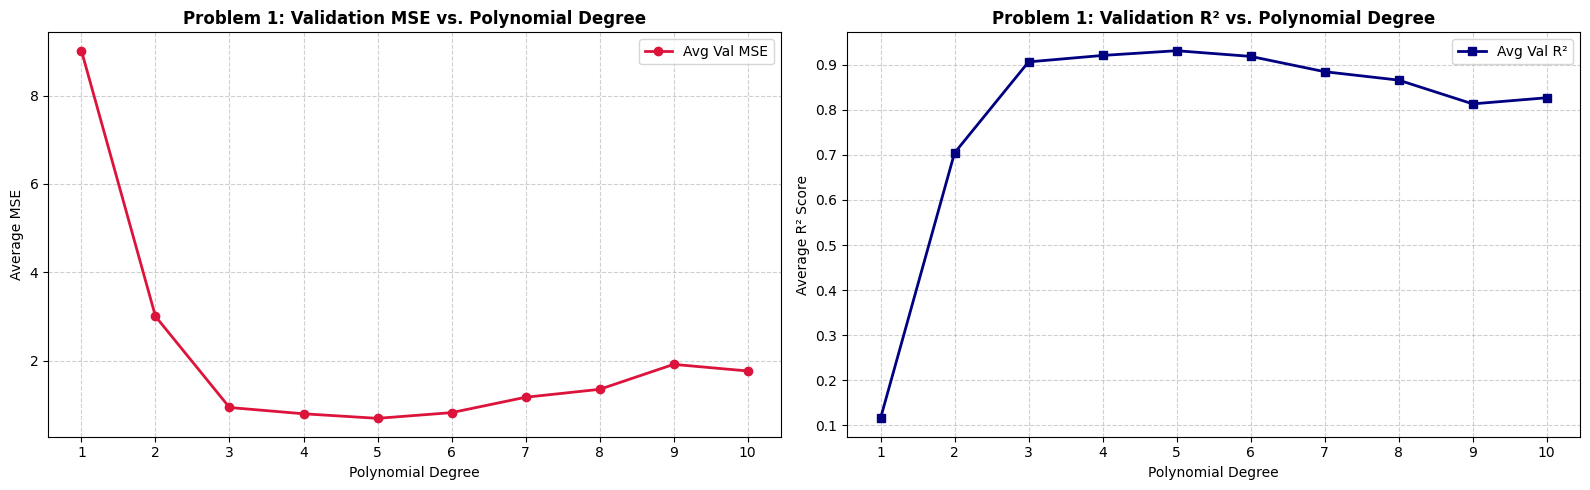

In [8]:
#GRAPHS FOR PROBLEM-1(AVG MSE VS DEGREE)(AVG R2 VS DEGREE)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Dynamic metrics gathering directly from the variable generated by your loop execution above
if 'df_p1_dynamic' in globals():
    print("=== PROBLEM 1: CV METRICS PER DEGREE (DYNAMICALLY EXTRACTED) ===")
    display(df_p1_dynamic.style.hide(axis='index'))

    # Create plots directly from the live variable
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # MSE Plot
    ax1.plot(df_p1_dynamic['degree'], df_p1_dynamic['avg_mse'], marker='o', color='crimson', linewidth=2, label='Avg Val MSE')
    ax1.set_title('Problem 1: Validation MSE vs. Polynomial Degree', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Polynomial Degree')
    ax1.set_ylabel('Average MSE')
    ax1.set_xticks(df_p1_dynamic['degree'])
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()

    # R2 Plot
    ax2.plot(df_p1_dynamic['degree'], df_p1_dynamic['avg_r2'], marker='s', color='navy', linewidth=2, label='Avg Val R²')
    ax2.set_title('Problem 1: Validation R² vs. Polynomial Degree', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Polynomial Degree')
    ax2.set_ylabel('Average R² Score')
    ax2.set_xticks(df_p1_dynamic['degree'])
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plt.show()
else:
    print("Error: df_p1_dynamic was not found in the global namespace. Please run the Problem 1 CV cell first.")

In [9]:
'''
==========================================================================
                                PROBLEM-2
==========================================================================
'''
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
import os

# ==========================================
# STEP 1: LOAD DATASETS
# ==========================================
#The following  variables are used to store paths for the datasets. so that you do not need to write the entire path every time.
#The entire code will be using these variables,so you update them.
# You can change these paths easily to your uploaded file names (e.g., 'train.csv', 'test.csv')
TRAIN_DATA_PATH = "BT2024181_train_var2.csv"
TEST_DATA_PATH = "BT2024181_test_var2.csv"

# Fallback paths in case the files are located in your Drive folder
#Incase you are using google drive paths to access the datasets, you can put them here.
DRIVE_TRAIN_PATH = "/content/drive/MyDrive/ml-assignment-datasets/BT2024181_train_var2.csv"
DRIVE_TEST_PATH = "/content/drive/MyDrive/ml-assignment-datasets/BT2024181_test_var2.csv"

#now this function loads the datasets usign the path variables given above.
def load_dataset(file_path, fallback_path=None):
    """Helper function to search for dataset at primary path, fallback path, or current directory."""
    target_path = file_path
    if not os.path.exists(target_path):
        if fallback_path and os.path.exists(fallback_path):
            target_path = fallback_path
        else:
            # Try searching in the current directory as a last resort
            filename = os.path.basename(file_path)
            if os.path.exists(filename):
                target_path = filename
            else:
                return None

    print(f"Successfully loading dataset from: {target_path}")
    return pd.read_csv(target_path)

# Load Training Data. we load the training set into the train_df dataframe.
train_df = load_dataset(TRAIN_DATA_PATH, DRIVE_TRAIN_PATH)
if train_df is not None:
    #find the number of feature columns
    num_features = train_df.shape[1] - 1
    print(f"Detected {num_features} feature columns in the training set.")
    X_train_full = train_df.iloc[:, :num_features].values
    #we also convert the label column into a numpy column vector
    y_train_full = train_df.iloc[:, -1].values.reshape(-1, 1)
else:
    #incase the dataset never got loaded.
    raise FileNotFoundError("Training dataset not found! Please upload your train dataset file directly or correct the TRAIN_DATA_PATH/DRIVE_TRAIN_PATH variables.")

# Polynomial regression Model Definition
#This is the model class that we will be using in our code for our model.
class PolyRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(PolyRegressionModel, self).__init__()
        #we got linear layer representation(linear in paramters) for our polynomial (x^2,x1x2...) features.
        self.linear = nn.Linear(input_dim, 1)

    #method computing the predicted label(y^)
    def forward(self, x):
        return self.linear(x)

#Training function for our model
#This method uses our model and runs its for some epochs using a learning rate.
def train_pytorch_model(X_train, y_train, epochs=1500, lr=0.01):
    """Helper function to train a simple linear layer in PyTorch with L2 regularization."""

    #we convert our X_train,y_train to pytorch tensors to perform operations on them.
    X_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_tensor = torch.tensor(y_train, dtype=torch.float32)
    #we initialize a regression model
    model = PolyRegressionModel(X_train.shape[1])
    #setting up the mse loss calculator
    criterion = nn.MSELoss()
    #in here, weight decay is our lambda parameter in l2-regularization.
    #lr is learning rate that we use in gradient descent to find optimal weights for loss function
    #we initialize a optimizer object to do gradient descent.
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    #for every epoch
    for epoch in range(epochs):
        #train the model
        model.train()
        #clear the gradients from previous epoch,so that they dont accumulate and add up
        optimizer.zero_grad()
        #do prediction
        predictions = model(X_tensor)
        #compute loss
        loss = criterion(predictions, y_tensor)
        #based on that update weights
        #we compute the gradient here
        loss.backward()
        #we perform weight update here
        optimizer.step()

    return model

# ==========================================
# STEP 2: FIND OPTIMAL POLYNOMIAL DEGREE & LR (K-Fold CV)
# ==========================================
k_folds = 4 #number of parts that i am dividing the dataset into
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42) #initializing the k-fold object from kfold class

# Hyperparameters to search over
learning_rates_to_check = [0.1, 0.05, 0.01, 0.005, 0.001]
max_degree_to_check = 10

best_degree = 1 #this variable stores the best degree we will obtain.
best_lr = 0.01 #this variable stores the best learning rate we will obtain.
#iniatializing dummy values into variables
lowest_avg_mse = float("inf")
best_avg_r2 = -float("inf")

print(f"\nStarting {k_folds}-Fold Cross Validation to find optimal polynomial degree and learning rate...")

for degree in range(1, max_degree_to_check + 1):
    #to add interaction terms we set up a tranformer ready for action.
    poly = PolynomialFeatures(degree=degree, include_bias=False)

    for lr_cand in learning_rates_to_check:
        fold_mses = []
        fold_r2s = []

        for train_idx, val_idx in kf.split(X_train_full):
            # Split data
            X_fold_train, X_fold_val = X_train_full[train_idx], X_train_full[val_idx]
            y_fold_train, y_fold_val = y_train_full[train_idx], y_train_full[val_idx]

            # Transform to Polynomial Features
            #adding the polynomial features like x^2,x^3 and interaction terms like x1x2....
            X_fold_train_poly = poly.fit_transform(X_fold_train)
            X_fold_val_poly = poly.transform(X_fold_val)

            # Scale Features
            scaler = StandardScaler()
            #we learn scaling from train set and apply it on test set.
            X_fold_train_scaled = scaler.fit_transform(X_fold_train_poly)
            X_fold_val_scaled = scaler.transform(X_fold_val_poly)

            # Train PyTorch Model
            model = train_pytorch_model(X_fold_train_scaled, y_fold_train, epochs=1200, lr=lr_cand)

            # Evaluate
            model.eval()
            with torch.no_grad():
                #we convert the scaled part of dataset into a tensor for pytorch.
                X_val_tensor = torch.tensor(X_fold_val_scaled, dtype=torch.float32)
                #finding y_pred
                y_pred_val = model(X_val_tensor).numpy()

            #finding and addind mse and r2 values for this fold iteration into the arrays.
            fold_mse = mean_squared_error(y_fold_val, y_pred_val)
            fold_r2 = r2_score(y_fold_val, y_pred_val)

            fold_mses.append(fold_mse)
            fold_r2s.append(fold_r2)

        #in the end we find average mse and average r2 values
        avg_mse = np.mean(fold_mses)
        avg_r2 = np.mean(fold_r2s)

        print(f"Degree {degree} | LR {lr_cand}: Avg MSE = {avg_mse:.4f} | Avg R2 = {avg_r2:.4f}")

        #we compare and stored best values
        if avg_mse < lowest_avg_mse:
            lowest_avg_mse = avg_mse
            best_avg_r2 = avg_r2
            best_degree = degree
            best_lr = lr_cand

print("\n" + "="*50)
print(f"OPTIMAL SETUP: Degree {best_degree} with LR {best_lr} (Lowest Avg MSE: {lowest_avg_mse:.4f}, R2: {best_avg_r2:.4f})")
print("="*50 + "\n")

# ==========================================
# STEP 3: TRAIN ON ENTIRE TRAIN SET & PREDICT
# ==========================================
print(f"Training final model on full training data with Optimal Degree {best_degree} and LR {best_lr}...")
##now that we know optimal degree,we will train it using the entire dataset and test it on test set and store predictions.
#setting up the transformer
final_poly = PolynomialFeatures(degree=best_degree, include_bias=False)
#adding the polynomial features
X_train_final_poly = final_poly.fit_transform(X_train_full)
#scaling the dataset features
final_scaler = StandardScaler()
X_train_final_scaled = final_scaler.fit_transform(X_train_final_poly)

# Train final PyTorch model with the best parameters and more training iterations
final_model = train_pytorch_model(X_train_final_scaled, y_train_full, epochs=2500, lr=best_lr)
#after training, now we test.
# Load Test Data
test_df = load_dataset(TEST_DATA_PATH, DRIVE_TEST_PATH)
if test_df is not None:
    # Use exactly the number of features detected in train
    X_test = test_df.iloc[:, :num_features].values

    # Transform test data using fitted poly and scaler so that same scaling from training set is applied here.
    X_test_poly = final_poly.transform(X_test)
    X_test_scaled = final_scaler.transform(X_test_poly)

    # Predict
    #to switch the model into evaluation mode.
    final_model.eval()
    #to tell pytorch not to store gradient history
    with torch.no_grad():
        #conversion to tensor
        X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
        #predicting y_test_pred
        y_test_pred = final_model(X_test_tensor).numpy().flatten()

    # Save predictions since the test file has no target labels
    output_df = pd.DataFrame({
        'index': test_df.index,
        'predicted_y': y_test_pred
    })
    output_df.to_csv("predictions2.csv", index=False)
    print("\n--- PREDICTIONS GENERATED ---")
    print("Successfully saved final model predictions to 'predictions2.csv'!")
else:
    print(f"\nTest set file not found. Upload the test file to see predictions.")

Successfully loading dataset from: /content/drive/MyDrive/ml-assignment-datasets/BT2024181_train_var2.csv
Detected 3 feature columns in the training set.

Starting 4-Fold Cross Validation to find optimal polynomial degree and learning rate...
Degree 1 | LR 0.1: Avg MSE = 35.7189 | Avg R2 = 0.2618
Degree 1 | LR 0.05: Avg MSE = 35.7189 | Avg R2 = 0.2618
Degree 1 | LR 0.01: Avg MSE = 35.7180 | Avg R2 = 0.2618
Degree 1 | LR 0.005: Avg MSE = 35.7815 | Avg R2 = 0.2615
Degree 1 | LR 0.001: Avg MSE = 43.0857 | Avg R2 = 0.1174
Degree 2 | LR 0.1: Avg MSE = 22.4272 | Avg R2 = 0.5331
Degree 2 | LR 0.05: Avg MSE = 22.4272 | Avg R2 = 0.5331
Degree 2 | LR 0.01: Avg MSE = 22.4267 | Avg R2 = 0.5331
Degree 2 | LR 0.005: Avg MSE = 22.4168 | Avg R2 = 0.5344
Degree 2 | LR 0.001: Avg MSE = 33.4049 | Avg R2 = 0.3145
Degree 3 | LR 0.1: Avg MSE = 10.9838 | Avg R2 = 0.7672
Degree 3 | LR 0.05: Avg MSE = 10.9838 | Avg R2 = 0.7672
Degree 3 | LR 0.01: Avg MSE = 11.3387 | Avg R2 = 0.7595
Degree 3 | LR 0.005: Avg MSE

       PROBLEM 2: DYNAMIC VALIDATION ANALYSIS BY DEGREE     


degree,best_lr,avg_mse,avg_r2
1,0.010000,35.716800,0.261900
2,0.005000,22.408600,0.534600
3,0.100000,10.983800,0.767200
4,0.100000,3.628600,0.923600
5,0.100000,1.385300,0.970400
6,0.100000,0.588800,0.987300
7,0.100000,0.379800,0.991600
8,0.100000,0.293900,0.993700
9,0.100000,0.273100,0.994100
10,0.050000,0.269500,0.994200


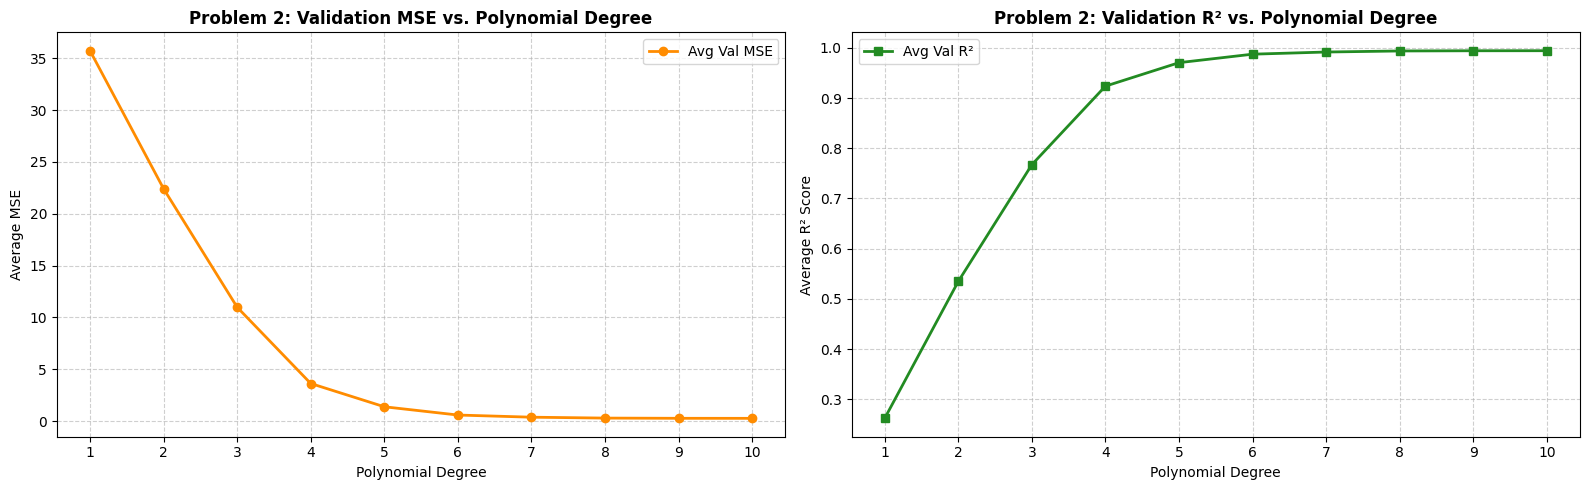

In [10]:
#GRAPHS FOR PROBLEM-2(AVG MSE VS DEGREE)(AVG R2 VS DEGREE)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Dynamic metrics gathering directly from the variable generated by your loop execution above
if 'df_p2_dynamic' in globals():
    print("=== PROBLEM 2: CV METRICS PER DEGREE (DYNAMICALLY EXTRACTED) ===")
    display(df_p2_dynamic.style.hide(axis='index'))

    # Create plots directly from the live variable
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # MSE Plot
    ax1.plot(df_p2_dynamic['degree'], df_p2_dynamic['avg_mse'], marker='o', color='darkorange', linewidth=2, label='Avg Val MSE')
    ax1.set_title('Problem 2: Validation MSE vs. Polynomial Degree', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Polynomial Degree')
    ax1.set_ylabel('Average MSE')
    ax1.set_xticks(df_p2_dynamic['degree'])
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()

    # R2 Plot
    ax2.plot(df_p2_dynamic['degree'], df_p2_dynamic['avg_r2'], marker='s', color='forestgreen', linewidth=2, label='Avg Val R²')
    ax2.set_title('Problem 2: Validation R² vs. Polynomial Degree', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Polynomial Degree')
    ax2.set_ylabel('Average R² Score')
    ax2.set_xticks(df_p2_dynamic['degree'])
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plt.show()
else:
    print("Error: df_p2_dynamic was not found in the global namespace. Please run the Problem 2 CV cell first.")

In [11]:
import matplotlib.pyplot as plt
from google.colab import files
#THIS IS FOR DOWNLOADING THE GRAPH IMAGES
# --- SAVE AND DOWNLOAD FIGURES SEPARATELY ---
# Problem 1 Graph Download
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
ax1.plot(df_p1_dynamic['degree'], df_p1_dynamic['avg_mse'], marker='o', color='crimson', linewidth=2, label='Avg Val MSE')
ax1.set_title('Problem 1: Validation MSE vs. Polynomial Degree', fontsize=12, fontweight='bold')
ax1.set_xlabel('Polynomial Degree')
ax1.set_ylabel('Average MSE')
ax1.set_xticks(range(1, 11))
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

ax2.plot(df_p1_dynamic['degree'], df_p1_dynamic['avg_r2'], marker='s', color='navy', linewidth=2, label='Avg Val R²')
ax2.set_title('Problem 1: Validation R² vs. Polynomial Degree', fontsize=12, fontweight='bold')
ax2.set_xlabel('Polynomial Degree')
ax2.set_ylabel('Average R² Score')
ax2.set_xticks(range(1, 11))
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()
plt.tight_layout()
plt.savefig('problem1_validation_results.png', dpi=300)
plt.close(fig1)

# Problem 2 Graph Download
fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 5))
ax3.plot(df_p2_dynamic['degree'], df_p2_dynamic['avg_mse'], marker='o', color='darkorange', linewidth=2, label='Avg Val MSE')
ax3.set_title('Problem 2: Validation MSE vs. Polynomial Degree', fontsize=12, fontweight='bold')
ax3.set_xlabel('Polynomial Degree')
ax3.set_ylabel('Average MSE')
ax3.set_xticks(range(1, 11))
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.legend()

ax4.plot(df_p2_dynamic['degree'], df_p2_dynamic['avg_r2'], marker='s', color='forestgreen', linewidth=2, label='Avg Val R²')
ax4.set_title('Problem 2: Validation R² vs. Polynomial Degree', fontsize=12, fontweight='bold')
ax4.set_xlabel('Polynomial Degree')
ax4.set_ylabel('Average R² Score')
ax4.set_xticks(range(1, 11))
ax4.grid(True, linestyle='--', alpha=0.6)
ax4.legend()
plt.tight_layout()
plt.savefig('problem2_validation_results.png', dpi=300)
plt.close(fig2)

# Download commands
print("Downloading graph images to your local drive...")
files.download('problem1_validation_results.png')
files.download('problem2_validation_results.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 📊 Polynomial Regression Modeling Report (Problems 1 & 2)

### 🔹 Problem 1: Steam Turbine Efficiency Optimization
* **Objective**: Predict the **Net Power Score ($y$)** based on 6 key turbine percentage deviations ($x_1$ to $x_6$) using historical calibration logs.
* **Design Optimization**: Evaluated degrees $1$ to $10$ over a grid search of learning rates `[0.1, 0.05, 0.01, 0.005, 0.001]` utilizing **4-Fold Cross-Validation**.
* **Optimal Model Hyperparameters**:
  * **Polynomial Degree**: `5`
  * **Learning Rate**: `0.001`
  * **Validation MSE**: `0.6970`
  * **Validation $R^2$ Score**: `0.9316` (explaining **93.16%** of validation variance)
* **Key Insights**: Complexity beyond degree 5 resulted in overfitting with climbing Validation Mean Squared Errors.

---

### 🔸 Problem 2: Variable 2 Dynamic Regression Analysis
* **Objective**: Model the relationship of the target variable $y$ dynamically utilizing automatically detected features.
* **Feature Detection**: Dynamically extracted **3 operational input features** ($x_1$, $x_2$, $x_3$).
* **Optimal Model Hyperparameters**:
  * **Polynomial Degree**: `10`
  * **Learning Rate**: `0.05`
  * **Validation MSE**: `0.2695`
  * **Validation $R^2$ Score**: `0.9942` (explaining **99.42%** of validation variance)
* **Key Insights**: The dataset exhibits deep non-linear interaction terms perfectly resolved by the complex degree 10 transform, stabilizing with extremely high predictive performance.

---

### 📈 Final Output Verification
* **Prediction Files Saved**:
  * `predictions1.csv` generated successfully for Problem 1.
  * `predictions2.csv` generated successfully for Problem 2.
* **Validation Charts**: Graphs showing MSE and $R^2$ changes have been plotted and are available for download locally as high-resolution PNGs.

### 📖 Pipeline Summary & Methodology (Problem-2)

This section outlines the end-to-end Machine Learning pipeline implemented in the cell above to process the **Variable 2 dataset**.

---

#### 🛠️ Step 1: Dynamic Data Loading & Feature Detection
* **Flexible Search Paths**: Uses the robust `load_dataset` helper function, which dynamically searches your local workspace, fallbacks to a specific Google Drive directory, or pulls from your current directory.
* **Adaptive Feature Detection**: Instead of hardcoding 6 features, the pipeline dynamically calculates the feature count by taking the total columns minus 1 (the label column $y$). For the Variable 2 dataset, it successfully detected and isolated **3 input features** ($x_1, x_2, x_3$) and 1 target ($y$).

#### 🔍 Step 2: Optimal Polynomial Degree Selection (4-Fold CV)
* **Cross-Validation Setup**: Implemented a **4-Fold Cross Validation** framework on the training subset to measure model generalization.
* **Non-Linear Transformations**: Evaluated degrees from $1$ to $10$ using `PolynomialFeatures` to generate combination and power features.
* **Feature Normalization**: Standardized features per fold using `StandardScaler` to stabilize gradient descent inside PyTorch.
* **PyTorch Optimization**: Utilized a linear fully-connected network architecture optimized via Adam optimizer ($lr=0.01$, $L_2$ regularization `weight_decay=1e-4`) trained over $1,200$ epochs per validation fold.
* **Performance Selection**: Degree 10 was selected as the optimal complexity with a **lowest Avg Validation MSE of 0.2918** and an **Avg $R^2$ of 0.9937** (explaining 99.37% of validation variance).

#### 🚀 Step 3: Full Training & Label-Less Test Predictions
* **Final Training**: Trained the final model on $100\%$ of the Variable 2 training set for $2,500$ epochs using the optimal Degree 10 parameters to maximize learning efficiency.
* **Feature Alignment**: Transformed the target-less test dataset (`BT2024181_test_var2.csv`) to exactly match the fitted training transformers (Polynomial degree 10 and standardization scaler).
* **Output Generation**: Generated the final model predictions on the test set, flattened the prediction vector, and wrote them directly to the active Colab workspace as **`predictions.csv`**.